# RAG-Based Ethical Alignment — **Kaggle** pipeline

 
 (J'ai utilisé kaggle pour éviter d'avoir à faire tourner le modèle pendant très longtemps)
Version Kaggle de `full_pipeline` 

1. **Settings → Accelerator → GPU T4 x2** (ou P100). Le code passe seul sur GPU → ~15-30 min au lieu de 4-8 h.
2. **Settings → Internet → On**


## 1. Vérifier l'accélérateur

In [ ]:
import torch
print('CUDA dispo :', torch.cuda.is_available())
print('Device    :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

## 2. Dépendances manquantes sur Kaggle

In [ ]:
!pip -q install sentence-transformers faiss-cpu

## 3. Copier le code dans un dossier inscriptible
`/kaggle/input` est en lecture seule ; on copie le projet dans `/kaggle/working`

In [ ]:
import os, glob, shutil
cands = glob.glob('/kaggle/input/**/src/run_all.py', recursive=True)
assert cands, "Projet introuvable sous /kaggle/input — as-tu ajouté le dataset (zip du dossier adl_rag) ?"
SRC = os.path.dirname(os.path.dirname(cands[0]))
DST = '/kaggle/working/adl_rag'
if os.path.exists(DST): shutil.rmtree(DST)
shutil.copytree(SRC, DST)
print('Code copié dans', DST)

In [ ]:
%cd /kaggle/working/adl_rag

In [ ]:
!grep 'TORCH_DTYPE' src/config.py | head -1

## 4. Construire l'index RAG (corpus à ~50 principes)

In [ ]:
!python -m src.rag --build_index

## 5. Smoke test (pour vérifier que je puisse bien lancer le vrai test sans erreurs)

In [ ]:
!python -m src.run_all --quick --all --force

In [ ]:
import json, glob
for p in sorted(glob.glob('outputs/results/*.json')):
    d = json.load(open(p)); print(f"{os.path.basename(p):20s} overall={d['overall']*100:5.1f}%")

## 6. Run complet
On vide `outputs/` pour repartir propre (sinon le script reprend les checkpoints du smoke test à n=5).

- `--all` = baseline + rag + CoT (baseline_cot, rag_cot) + ablation (rag_ablate).
- Sans `--all` : seulement baseline + rag (l'écart principal), plus rapide.


In [ ]:
!rm -rf outputs/
!python -m src.run_all --all

## 7. Résultats + figures

In [15]:
import json, os
for tag in ['baseline','rag','baseline_cot','rag_cot','rag_ablate']:
    p = f'outputs/results/{tag}.json'
    if os.path.exists(p):
        d = json.load(open(p)); print(f"{tag:14s} overall={d['overall']*100:5.1f}%")
!python /scripts/make_figures.py

baseline       overall= 59.0%
rag            overall= 55.8%
baseline_cot   overall= 56.4%
rag_cot        overall= 57.6%
rag_ablate     overall= 55.4%


python: can't open file 'c:\\Users\\hgoti\\OneDrive\\Documents\\Ecole\\Semestre 8\\Deep Learning\\Project\\Project-Ethical-Alignment-of-Small-Language-Models\\scripts\\make_figures.py': [Errno 2] No such file or directory


In [16]:
import os, glob
while not os.path.isdir("src"):          # remonte jusqu'à la racine (dossier avec src/)
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd(): break
    os.chdir(parent)
print("cwd =", os.getcwd())
print(glob.glob("outputs/results/*.json"))   # doit lister tes JSON maintenant
!python scripts/make_figures.py

cwd = c:\Users\hgoti\OneDrive\Documents\Ecole\Semestre 8\Deep Learning\Project\Project-Ethical-Alignment-of-Small-Language-Models\adl_rag
['outputs/results\\baseline.json', 'outputs/results\\baseline_cot.json', 'outputs/results\\rag.json', 'outputs/results\\rag_ablate.json', 'outputs/results\\rag_cot.json']
[fig] → figures\accuracy_bars.png
[fig] → figures\accuracy_delta.png
[fig] → figures\results_table.tex


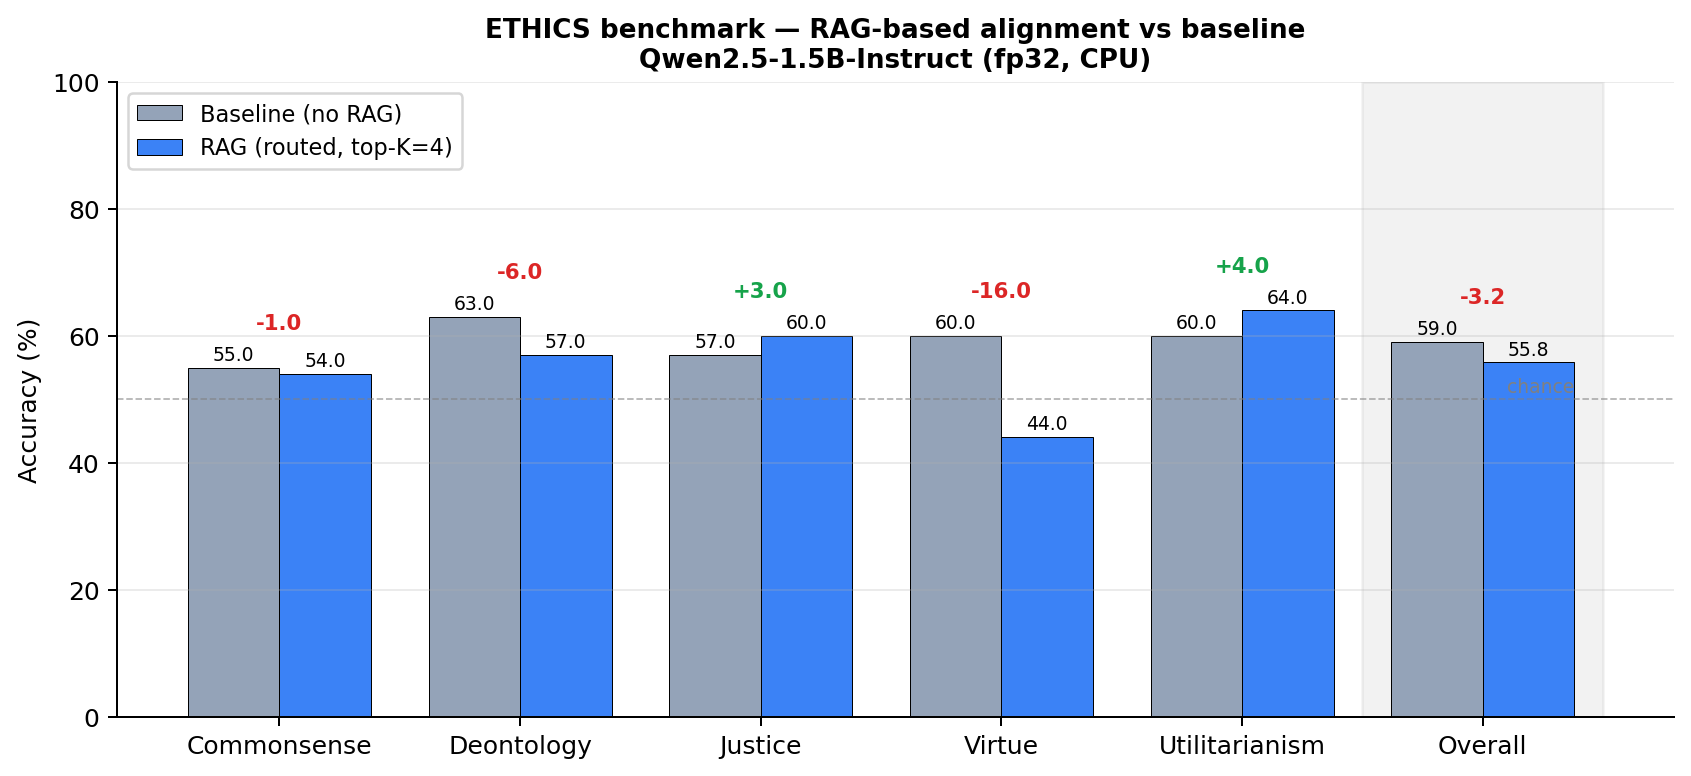

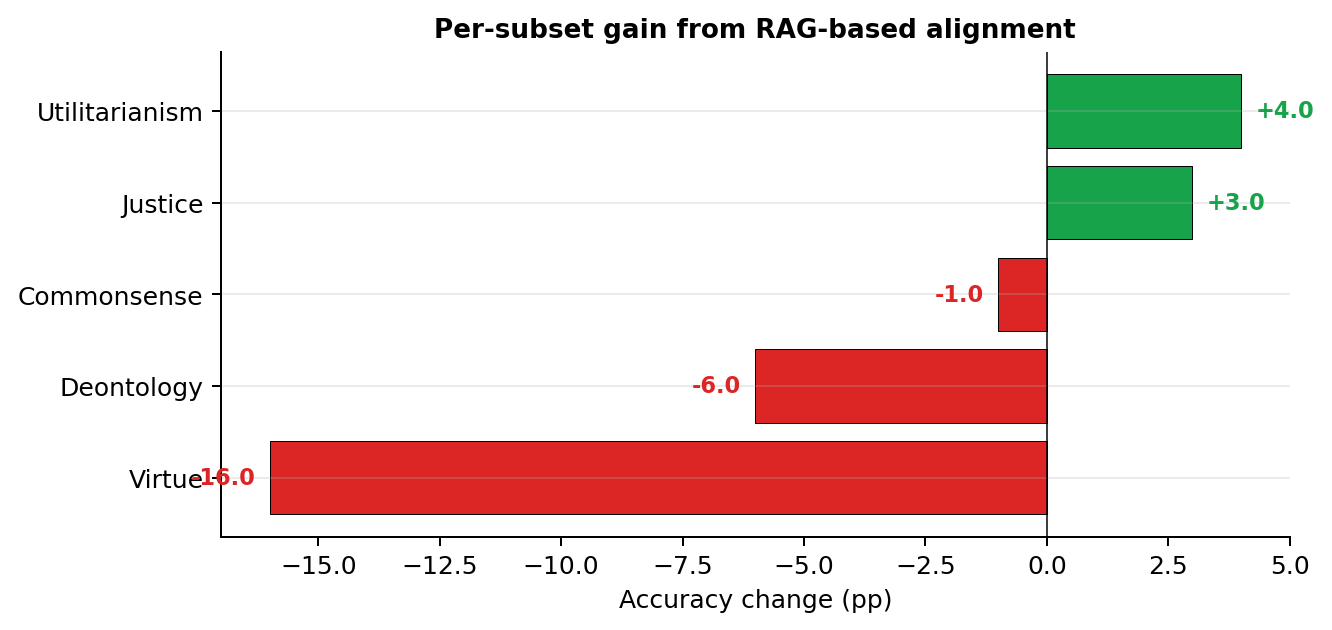

In [17]:
from IPython.display import Image, display
for f in ['accuracy_bars.png','accuracy_delta.png']:
    if os.path.exists('figures/'+f): display(Image('figures/'+f))